## Import Library

In [1]:
import numpy as np
import pandas as pd
import sympy 
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from sympy import init_printing
from sympy.utilities.lambdify import lambdify
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting
from matplotlib import cm  # colormap
init_printing(use_latex=True)

# Domain Discretization

In [ ]:
#set several domain data discrete
element_num_x = 101 #we set 101
element_num_y = 51 #we set 51
a,b = 0,2 #set the x bound
c,d = 0,1 #set the y bound
dx = (b-a)/(element_num_x-1)  #set the dx length
dy = (d-c)/((element_num_y-1))  #set the dy length
convergence_res = 0.0001 #smaller means the source term diffuse better

#mesh to visualize and numerically matter
x_vals = np.linspace(a,b,element_num_x) #set the x axis
y_vals = np.linspace(c,d,element_num_y) #set the y axis
X, Y = np.meshgrid(x_vals, y_vals) #set for meshgrid

#set for boundary condition
p = np.zeros([element_num_y,element_num_x])
p[:,0] = 0      #set the x = 0 ,P = 0
p[:,100] = y_vals       #set the x = 2 ,P = y

#set for nonhomogenouos (source) term
B = np.zeros([element_num_y,element_num_x])
B[int(0.25/dy),int(0.5/dx)] = 100
B[int(0.75/dy),int(1.5/dx)] = -100

## Poisson Numerically

In [ ]:
def Poisson_Numerically(dx,dy,p,B,convergence_res):

    l1norm = 1  #initialize value

    while l1norm > convergence_res:

        p_new = p.copy()
        #we calculate the horizontal first then vertically declined after the horizontal is done
        
        for i in range (1,len(p[:,0])-1): #define the y each iteration

            for j in range (1,len(p[0])-1): #define the x each iteration

                #numeric laplace procedure
                p_new[i,j] = (
                    ((p[i,j+1] + p[i,j-1]) * dy**2 +
                     (p[i+1,j] + p[i-1,j]) * dx**2 - B[i,j] * dx**2 * dy**2)
                    / (2 * (dx**2 + dy**2))
                )
            
        p_new[:,0] = 0      #set the x = 0 ,P = 0 dirichlet
        p_new[:,-1] = 0       #set the x = 2 ,P = 0 dirichlet
        p_new[0,  :] = 0  #set the dirichlet boundary
        p_new[-1, :] = 0 #set the dirichlet boundary

        #calculate the error and pass to next calculation to reduce error
        l1norm = np.abs(np.sum(np.abs(p_new[:]) - np.abs(p[:]))/(np.sum(np.abs(p[:])))) 
        print(f'convergence residual: {l1norm}')
        p = p_new

    return p_new

## Visualization

0.7590196078401608
0.2561025223717477
0.16652994257223888
0.12342109579728551
0.09635313106450835
0.07847527827852842
0.06523097883103234
0.055329583486157324
0.04738653278817335
0.04103978124742237
0.03570867215332722
0.03127082411382847
0.027432276552891627
0.024148552156505618
0.021251320154240867
0.018725052460553056
0.016464657821278168
0.014466181475983263
0.012659706520372432
0.011046002727888042
0.009576243928797499
0.008253036523431258
0.007040961666662987
0.005943199376023259
0.004933260950159979
0.004014345857330347
0.003166144154417018
0.002391642699066766
0.0016749438217834574
0.0010187391301597131
0.00041036674754457215
0.00014779054285054554
0.0006659671507445437
0.001142072063978007
0.0015844826991748939
0.00199137075575508
0.002369668780342467
0.002717779084753399
0.0030414932452083676
0.003339413213840766
0.003616417799161327
0.0038712805092594982
0.004108141537660617
0.0043259213140534325
0.0045281562546350546
0.004713892509431721
0.004886168474893468
0.0050441379764

Text(0, 0.5, '$y$')

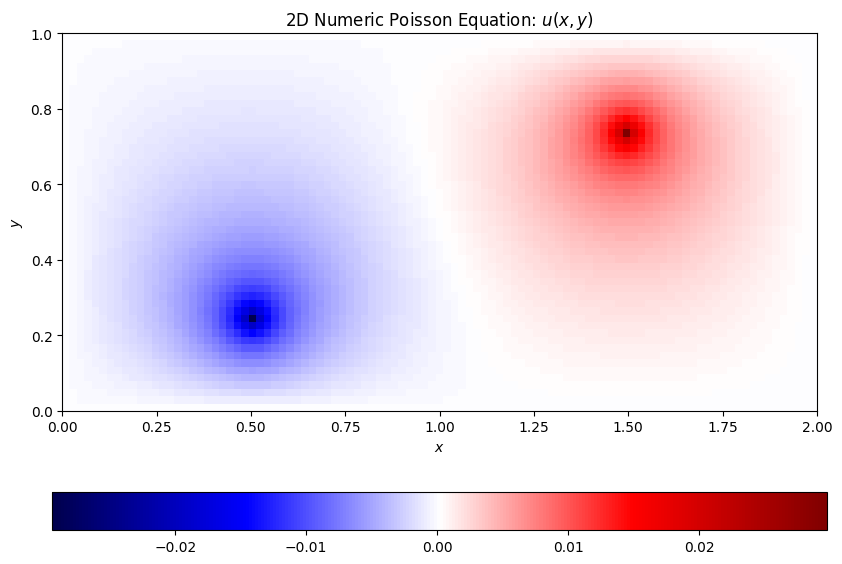

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))  #initialize the figure by subplots

P_numeric = Poisson_Numerically(dx,dy,p,B,convergence_res)

# Inisialisasi heatmap awal
cax = ax.imshow(P_numeric, cmap='seismic', origin='lower', extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)], vmin=np.min(P_numeric), vmax=np.max(P_numeric)) #extent to visualize 
cbar = fig.colorbar(cax, ax=ax, orientation = 'horizontal')
cbar.ax.xaxis.set_label_position('bottom')
cbar.ax.xaxis.tick_bottom()  # Put ticks on top
ax.set_title('2D Numeric Poisson Equation: $u(x, y)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

#res_1,res_2 = Laplace_Analytically(X,Y)